# Fig 2: TTFT vs Input Length (Cached vs Uncached)

**Output:** `model_outputs/<MODEL_SHORT>/paper/section3/fig2/prefill_linearity.{pdf,png}`, `prefill_with_cache.{pdf,png}`

Paths are resolved via `MODEL_DATA_DIR` from `profiling/config.py` (set `MODELS_ROOT` in `config.env` to override).

### Call order
1. Auto-generate any missing long-prompt files (`model_outputs/<MODEL_SHORT>/long_prompts/`)
2. `profiling/launch_prefill_profile.sh` — collect cold-prefill data (~30–60 min, GPUs 1–3; writes to `model_outputs/<MODEL_SHORT>/paper/section3/profiling/prefill_profile_data/`)
3. `profiling/run_cache_cost.py` — collect cache-hit/miss data (writes to `model_outputs/<MODEL_SHORT>/paper/section3/profiling/cache_cost_data/`)
4. `scripts/plot_cache_cost.py` — parse cache data → `cache_cost_table.csv`
5. `scripts/plot_prefill_linearity.py` — cold-prefill scatter + quadratic fit
6. `scripts/plot_prefill_with_cache.py` — overlays cache-hit curve

Steps 2–3 collect raw data and only need to be run once. If data is already present the collect cells are safe to re-run (they skip existing output).

In [1]:
import subprocess
from pathlib import Path

REPO_ROOT = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / ".conserve_root").exists()
)


def run(cmd):
    buf = []
    with subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
    ) as proc:
        for line in proc.stdout:
            print(line, end="", flush=True)
            buf.append(line)
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed (exit {proc.returncode}): {' '.join(str(c) for c in cmd)}")
    return "".join(buf)


In [2]:
# Ensure all required long-prompt files exist; generate any that are missing.
import sys
sys.path.insert(0, str(REPO_ROOT / "profiling"))
from config import MODEL_DATA_DIR, MODEL_SHORT

REQUIRED_LENGTHS = [
    1, 2, 4, 8, 16, 32, 64,
    128, 256, 512, 1024, 2048, 4096, 6144,
    10240, 12288, 16384, 20480, 24576, 28672, 32768,
    65536,
]
prompt_dir = MODEL_DATA_DIR / "long_prompts"
missing = [L for L in REQUIRED_LENGTHS if not (prompt_dir / f"prompts_{L}x2048.json").exists()]

if missing:
    print(f"[{MODEL_SHORT}] generating prompt files for L = {missing}")
    run(["python", str(REPO_ROOT / "profiling/long_prompts/generate_long_prompts.py"),
         "--targets", ",".join(str(L) for L in missing)])
else:
    print(f"[{MODEL_SHORT}] all prompt files present, skipping generation")


[Qwen3-0.6B] generating prompt files for L = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 6144, 10240]
[Qwen3-0.6B] seed tokenized lengths — min=8191 max=8191 median=8191
[Qwen3-0.6B] generating L=1 (2048 prompts)…
  L=1: 0/2048
  L=1: 256/2048
  L=1: 512/2048
  L=1: 768/2048
  L=1: 1024/2048
  L=1: 1280/2048
  L=1: 1536/2048
  L=1: 1792/2048
  wrote prompts_1x2048.json: min=1 max=1 target=1  exact_match=2048/2048
[Qwen3-0.6B] generating L=2 (2048 prompts)…
  L=2: 0/2048
  L=2: 256/2048
  L=2: 512/2048
  L=2: 768/2048
  L=2: 1024/2048
  L=2: 1280/2048
  L=2: 1536/2048
  L=2: 1792/2048
  wrote prompts_2x2048.json: min=2 max=2 target=2  exact_match=2048/2048
[Qwen3-0.6B] generating L=4 (2048 prompts)…
  L=4: 0/2048
  L=4: 256/2048
  L=4: 512/2048
  L=4: 768/2048
  L=4: 1024/2048
  L=4: 1280/2048
  L=4: 1536/2048
  L=4: 1792/2048
  wrote prompts_4x2048.json: min=4 max=4 target=4  exact_match=2048/2048
[Qwen3-0.6B] generating L=8 (2048 prompts)…
  L=8: 0/2048
  L=8: 256/2048
 

In [3]:
# Steps 1-2: collect raw profiling data. Skip if data already exists.
run(["bash", str(REPO_ROOT / "profiling/launch_prefill_profile.sh")])

GPU 1  ←  L = 65536,28672,16384,6144,512
GPU 2  ←  L = 57344,32768,24576,10240,2048,128
GPU 3  ←  L = 49152,40960,20480,12288,8192,4096,1024,256

Waiting for shards...


  shard 0 (pid 2421861) OK
  shard 1 (pid 2421862) OK
  shard 2 (pid 2421863) OK
All shards done.


'GPU 1  ←  L = 65536,28672,16384,6144,512\nGPU 2  ←  L = 57344,32768,24576,10240,2048,128\nGPU 3  ←  L = 49152,40960,20480,12288,8192,4096,1024,256\n\nWaiting for shards...\n  shard 0 (pid 2421861) OK\n  shard 1 (pid 2421862) OK\n  shard 2 (pid 2421863) OK\nAll shards done.\n'

In [4]:
run(["python", str(REPO_ROOT / "profiling/run_cache_cost.py")])

INFO 06-24 22:44:40 [__init__.py:216] Automatically detected platform cuda.
INFO 06-24 22:44:42 [utils.py:233] non-default args: {'download_dir': '/data/projects/eicchen/conserve_project/conserve/models_download', 'max_model_len': 81920, 'enable_prefix_caching': True, 'max_num_batched_tokens': 67584, 'max_num_seqs': 64, 'disable_log_stats': True, 'rope_scaling': {'rope_type': 'dynamic', 'factor': 2.5}, 'enforce_eager': True}
WARNING 06-24 22:44:42 [model.py:371] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 06-24 22:44:43 [model.py:547] Resolved architecture: Qwen3ForCausalLM
`torch_dtype` is deprecated! Use `dtype` instead!
INFO 06-24 22:44:43 [model.py:1510] Using max model len 81920
INFO 06-24 22:44:43 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=67584.
INFO 06-24 22:44:43 [__init__.py:381] Cudagraph is disabled under eager mode
No 

'INFO 06-24 22:44:40 [__init__.py:216] Automatically detected platform cuda.\nINFO 06-24 22:44:42 [utils.py:233] non-default args: {\'download_dir\': \'/data/projects/eicchen/conserve_project/conserve/models_download\', \'max_model_len\': 81920, \'enable_prefix_caching\': True, \'max_num_batched_tokens\': 67584, \'max_num_seqs\': 64, \'disable_log_stats\': True, \'rope_scaling\': {\'rope_type\': \'dynamic\', \'factor\': 2.5}, \'enforce_eager\': True}\nWARNING 06-24 22:44:42 [model.py:371] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.\nINFO 06-24 22:44:43 [model.py:547] Resolved architecture: Qwen3ForCausalLM\n`torch_dtype` is deprecated! Use `dtype` instead!\nINFO 06-24 22:44:43 [model.py:1510] Using max model len 81920\nINFO 06-24 22:44:43 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=67584.\nINFO 06-24 22:44:43 [__init__.py:381] Cudagraph 

    L  miss_p50  miss_mean  miss_std  hit_p50  hit_mean  hit_std  n
  128    14.894    14.9190  0.173558   13.421   13.4646 0.144213  5
  256    14.849    14.8576  0.050949   13.289   13.3356 0.109847  5
  512    14.893    14.8450  0.148901   13.367   13.3440 0.050853  5
 1024    19.962    19.9938  0.097189   13.426   13.4340 0.034227  5
 2048    37.109    37.1430  0.084655   13.613   13.6230 0.068982  5
 4096    81.428    81.0946  0.683220   20.945   18.1986 3.984074  5
 6144   131.466   131.4750  0.513711   14.291   15.5628 2.897248  5
 8192   194.310   194.2892  0.240491   14.837   14.8454 0.136097  5
10240   263.123   263.1486  0.151619   15.490   15.5326 0.316373  5
12288   350.192   350.1756  0.435499   17.255   17.2366 0.093310  5
16384   563.271   563.1500  0.506600   21.145   21.1548 0.139584  5
20480   821.825   821.2064  1.346227   24.940   25.4924 1.243502  5
24576  1132.282  1132.7908  2.747697   28.611   28.6242 0.153107  5
28672  1480.692  1481.1586  1.048154   32.195   

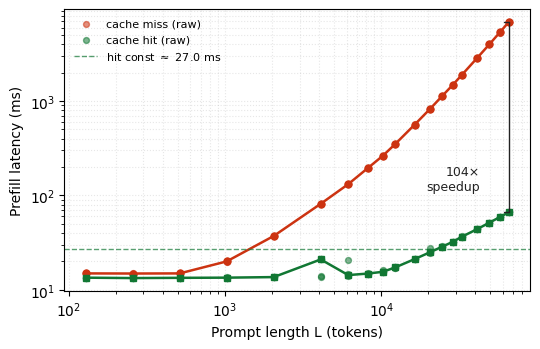

    L  n     mean_ms  median_ms     p25_ms     p75_ms     p99_ms     std_ms
  128 98   12.955418    12.8955   12.85325   12.93500   14.03998   0.262541
  256 98   13.105571    13.0890   13.05550   13.13250   13.63518   0.108388
  512 98   13.304837    13.2060   13.13550   13.33050   14.48722   0.329428
 1024 98   19.101724    19.0950   19.08125   19.10700   19.21899   0.048441
 2048 98   37.610367    37.5760   37.38525   37.81175   38.02835   0.238768
 4096 98   83.376857    83.3755   83.17975   83.52875   84.17175   0.246552
 6144 98  137.544684   137.5125  137.41475  137.63125  138.32427   0.203719
 8192 98  207.882929   207.3405  206.54250  208.48575  217.39639   3.594095
10240 98  281.117235   280.3775  279.27775  281.61375  285.60498   7.029235
12288 98  382.014224   379.6765  376.45850  382.14825  447.05030  13.115951
16384 98  594.753582   594.8630  594.28075  595.27550  597.05032   0.841359
20480 98  892.123847   890.0115  888.29900  895.81425  915.54820   6.902042
24576 98 121

<Figure size 640x480 with 0 Axes>

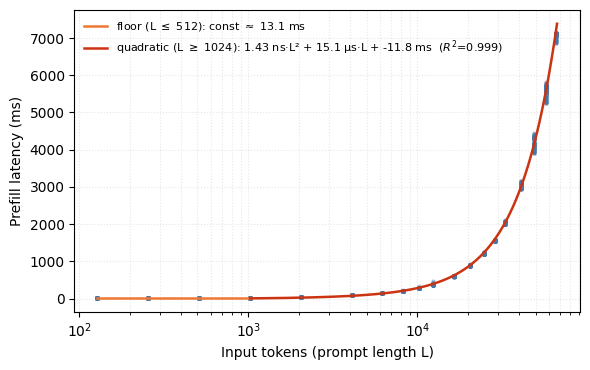

Cache-miss sanity check (cache_cost medians vs prefill_profile quadratic):
     L   cache_cost   quad_pred   profile_med   cc_resid
   128        14.89       -9.83         12.90     +24.72
   256        14.85       -7.82         13.09     +22.67
   512        14.89       -3.66         13.21     +18.55
  1024        19.96        5.22         19.10     +14.75
  2048        37.11       25.22         37.58     +11.89
  4096        81.43       74.21         83.38      +7.22
  6144       131.47      135.18        137.51      -3.72
  8192       194.31      208.15        207.34     -13.84
 10240       263.12      293.09        280.38     -29.97
 12288       350.19      390.03        379.68     -39.84
 16384       563.27      619.85        594.86     -56.58
 20480       821.83      897.62        890.01     -75.80
 24576      1132.28     1223.33       1209.78     -91.05
 28672      1480.69     1596.99       1560.62    -116.30
 32768      1886.88     2018.59       2021.34    -131.71
 40960      2

<Figure size 640x480 with 0 Axes>

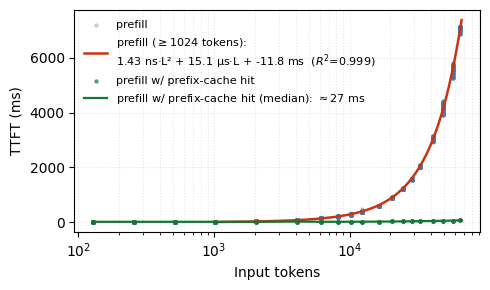

<Figure size 640x480 with 0 Axes>

In [7]:
# Steps 3-5: plot
%matplotlib inline
%run ../scripts/plot_cache_cost.py
%run ../scripts/plot_prefill_linearity.py
%run ../scripts/plot_prefill_with_cache.py